<a href="https://colab.research.google.com/github/Manawariqbal/Data-science-code/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [6]:
X,y=make_blobs(n_samples=500,n_features=5,centers=3,cluster_std=1.5,random_state=42)


X


array([[ -9.85712583,   9.52196609,   6.40680626,  -6.81757623,
         -7.86054541],
       [ -8.04717781,   8.40261648,   6.40946097,  -4.33576029,
         -6.70289196],
       [ -3.73690895,   6.7601386 ,   4.24877609,   0.28504117,
         -7.10318219],
       ...,
       [ -5.82805   ,  -7.29173339,   7.48633693,   2.71623974,
          7.33823548],
       [ -2.48648271,   9.67739715,   6.21190845,   1.03031506,
         -7.54637531],
       [ -8.63901448, -10.68852991,   8.36601977,   4.94211449,
          3.77070371]])

In [9]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)



array([[ -9.85712583,   9.52196609,   6.40680626,  -6.81757623,
         -7.86054541],
       [ -8.04717781,   8.40261648,   6.40946097,  -4.33576029,
         -6.70289196],
       [ -3.73690895,   6.7601386 ,   4.24877609,   0.28504117,
         -7.10318219],
       ...,
       [ -5.82805   ,  -7.29173339,   7.48633693,   2.71623974,
          7.33823548],
       [ -2.48648271,   9.67739715,   6.21190845,   1.03031506,
         -7.54637531],
       [ -8.63901448, -10.68852991,   8.36601977,   4.94211449,
          3.77070371]])

In [14]:
#PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

X_pca

array([[ 1.40522818e+00, -1.73079914e+00],
       [ 1.03463536e+00, -9.82792414e-01],
       [ 1.10182830e+00,  1.09084050e+00],
       [-1.76465839e+00,  1.09970698e-01],
       [ 8.59673831e-01, -1.63970361e+00],
       [ 1.09738958e+00,  1.11937509e+00],
       [ 1.04453451e+00,  1.88953610e+00],
       [-3.14810185e+00, -1.06909853e-01],
       [-1.34287183e+00,  7.48033000e-01],
       [ 4.59419122e-01,  9.66806100e-01],
       [ 1.64897776e+00,  1.95384681e+00],
       [ 7.73369393e-01,  2.09584610e+00],
       [-1.92869648e+00,  9.48608771e-02],
       [ 1.15480661e+00, -1.42564791e+00],
       [ 7.07330515e-01, -1.01056640e+00],
       [ 1.59661674e+00, -1.64931961e+00],
       [-2.40550592e+00, -7.53357753e-01],
       [-1.97627695e+00, -3.59747020e-02],
       [ 1.26193015e+00,  2.72813008e+00],
       [ 1.58339885e+00, -1.46125327e+00],
       [ 1.61435981e+00,  1.29812279e+00],
       [-1.74438705e+00,  1.58820049e-01],
       [-1.88938008e+00,  3.66662930e-01],
       [ 6.

In [16]:
df_pca=pd.DataFrame(
    X_pca,
    columns=['PC1','PC2']
)
df_pca['label']=y
df_pca.head()

,PC1,PC2,label
0,1.405228,-1.730799,2
1,1.034635,-0.982792,2
2,1.101828,1.090840,0
3,-1.764658,0.109971,1
4,0.859674,-1.639704,2


<Axes: xlabel='PC1', ylabel='PC2'>

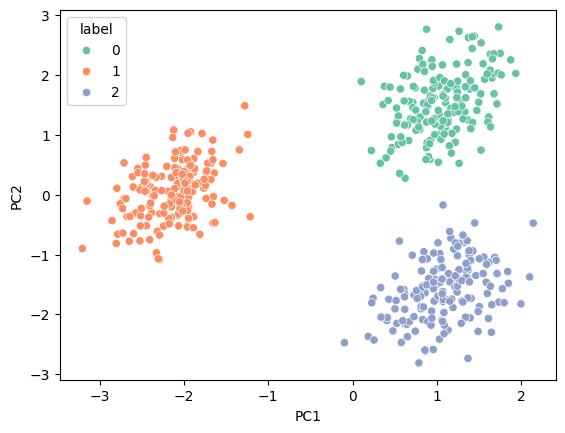

In [17]:
sns.scatterplot(data=df_pca,x='PC1',y='PC2',hue='label',palette='Set2')

In [19]:
#How much information our PC preserve
pca.explained_variance_ratio_
pca.explained_variance_ratio_.sum()

np.float64(0.8582383903281798)

In [21]:
#How many components should we select
pca_all=PCA()
pca_all.fit(X_scaled)
variance=pca_all.explained_variance_ratio_
variance

array([0.48303938, 0.37519901, 0.10093897, 0.03137499, 0.00944765])

In [23]:
#Calculate commulative variance
import numpy as np
commulative_variance=np.cumsum(variance)
commulative_variance

array([0.48303938, 0.85823839, 0.95917736, 0.99055235, 1.        ])

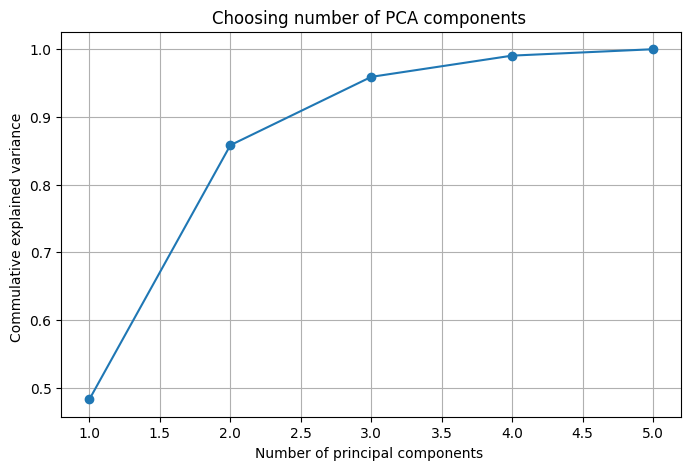

In [24]:
plt.figure(figsize=(8,5))
plt.plot(

         range(1,len(commulative_variance)+1),
         commulative_variance,
         marker='o'
)

plt.xlabel("Number of principal components ")
plt.ylabel("Commulative explained variance ")
plt.title("Choosing number of PCA components ")
plt.grid()
plt.show()

In [29]:
#Autoamtice selection of components
#we can ask PCA to preserve 95% of the varience
pca_95=PCA(n_components=0.90)
pca_95=pca_95.fit_transform(X_scaled)
pca_95.shape

(500, 3)

In [36]:
#HW
#Breast cancer data set
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
X=data.data
